In [1]:
import numpy as np
from numpy.random import default_rng
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tqdm.notebook import tqdm
from scipy.interpolate import UnivariateSpline
from scipy.stats import gaussian_kde, sem
from matplotlib.patches import Circle
from matplotlib.colors import to_rgb
from sklearn.linear_model import LinearRegression
from my_utils import *

from pathlib import Path
import sys
import warnings

In [2]:
modelpath = Path('../model')
sys.path.append(str(modelpath))
import config.config as config

arg = config.ConfigGain()
arg.device = 'cpu'

# Load monkey data

In [3]:
data_path = Path.cwd().parents[1] / 'monkey_data/BCM/Bruno'
bruno_normal_trajectory = pd.read_pickle(data_path / 'bruno_normal_trajectory_paper.pkl')
bruno_normal_trajectory_all = deepcopy_pd(bruno_normal_trajectory, is_df=True)
bruno_gain_trajectory = pd.read_pickle(data_path / 'bruno_gain_trajectory_paper.pkl')
bruno_gain_trajectory_all = deepcopy_pd(bruno_gain_trajectory, is_df=True)

data_path = Path.cwd().parents[1] / 'monkey_data/BCM/Schro'
schro_normal_trajectory = pd.read_pickle(data_path / 'schro_normal_trajectory_paper.pkl')
schro_normal_trajectory_all = deepcopy_pd(schro_normal_trajectory, is_df=True)
schro_gain_trajectory = pd.read_pickle(data_path / 'schro_gain_trajectory_paper.pkl')
schro_gain_trajectory_all = deepcopy_pd(schro_gain_trajectory, is_df=True)

In [4]:
# Match monkeys
EPISODE_SIZE = 1000
bruno_normal_trajectory, schro_normal_trajectory = match_similar_trials(bruno_normal_trajectory, 
                                                                        schro_normal_trajectory, 
                                                                        is_sort=True, EPISODE_SIZE=EPISODE_SIZE)
bruno_gain_trajectories = [bruno_normal_trajectory] + \
                          [match_similar_trials(bruno_gain_trajectory[bruno_gain_trajectory.gain_v == gain_v], 
                                                bruno_normal_trajectory) 
                           for gain_v in bruno_gain_trajectory.gain_v.unique()]
schro_gain_trajectories = [schro_normal_trajectory] + \
                          [match_similar_trials(schro_gain_trajectory[schro_gain_trajectory.gain_v == gain_v], 
                                                schro_normal_trajectory) 
                           for gain_v in schro_gain_trajectory.gain_v.unique()]

In [5]:
# Simulate no generalization cases
monkey_names = ['bruno', 'schro']

for monk_name in monkey_names:
    for idx, gain_df in enumerate(eval(f'{monk_name}_gain_trajectories')):
        normal_df = match_similar_trials(eval(f'{monk_name}_normal_trajectory_all'), gain_df, replace=True)
        locals()[f'{monk_name}_gain_trajectories'][idx] = simulate_no_generalization(gain_df, 
                                                                                     normal_df, subject='monkey')

# Choose agents

In [6]:
def select_agents(progress_agents_path, agent_archs, MAX_TRAINING_T, task='gain'):
    perform_files = [[pd.read_csv(file)[(pd.read_csv(file).episode > 0) & (pd.read_csv(file).episode < MAX_TRAINING_T)] 
                      for file in (Path.cwd().parent / 'model' / 'training_curve' / task).glob(f'{agent_arch}*.*')] 
                     for agent_arch in agent_archs]
    
    seeds = [[''.join(filter(str.isdigit, file.stem.split('_')[1]))
              for file in (Path.cwd().parent / 'model' / 'training_curve' / task).glob(f'{agent_arch}*.*')] 
             for agent_arch in agent_archs]
    best_seeds = [seed[np.argmax([np.sum([file[file.task == task].reward_rate 
                                          for task in file.task.unique()], axis=0).max()
                                  for file in perform_file])] 
                  for perform_file, seed in zip(perform_files, seeds)]
    best_files_idx = [np.argmax([np.sum([file[file.task == task].reward_rate 
                                         for task in file.task.unique()], axis=0).max()
                                 for file in perform_file]) 
                      for perform_file in perform_files]
    
    best_paths = [progress_agents_path / agent_arch / task / f'seed{seed}'
                  for agent_arch, seed in zip(agent_archs, best_seeds)]
    
    best_files = [perform_file[file_idx] for perform_file, file_idx in zip(perform_files, best_files_idx)]
    best_episodes = [file.episode.unique()[np.sum([file[file.task == task].reward_rate 
                                                   for task in file.task.unique()], axis=0).argmax()] 
                     for file in best_files]

    best_agents = [list(best_path.glob(f'*-{best_episode}.*'))[0].stem.split('.')[0]
                   for best_path, best_episode in zip(best_paths, best_episodes)]
    
    return best_seeds, best_paths, best_agents, perform_files

In [7]:
Models = {'Holistic_Actor': 'Actor1', 'Holistic_Critic': 'Critic1',
          'Modular_Actor': 'Actor3', 'Modular_Critic': 'Critic5'}
for k, v in Models.items():
    exec(f'from {v} import {v[:-1]} as {k}')

progress_agents_path = Path.cwd().parents[1] / 'agents'
agent_archs = [Models['Holistic_Actor'] + Models['Holistic_Critic'], 
               Models['Modular_Actor'] + Models['Holistic_Critic'],
               Models['Holistic_Actor'] + Models['Modular_Critic'],
               Models['Modular_Actor'] + Models['Modular_Critic']]

MAX_TRAINING_T = 1e5
task = 'gain'

In [8]:
best_seeds, best_paths, best_agents, perform_files = select_agents(progress_agents_path, 
                                                                   agent_archs, 
                                                                   MAX_TRAINING_T=MAX_TRAINING_T,
                                                                   task=task)

In [9]:
def select_agents_all(progress_agents_path, agent_archs, MAX_TRAINING_T, task='gain'):    
    seeds = [[''.join(filter(str.isdigit, file.stem.split('_')[1]))
              for file in (Path.cwd().parent / 'model' / 'training_curve' / task).glob(f'{agent_arch}*.*')] 
             for agent_arch in agent_archs]
    
    agent_paths = []; agent_files = []
    for agent_arch, seeds_ in zip(agent_archs, seeds): # loop each agent
        agent_path = []; agent_file = []
        for seed in seeds_:
            perform_file_path = Path.cwd().parent / 'model' / 'training_curve' / task / f'{agent_arch}_seed{seed}.csv'
            perform_file = pd.read_csv(perform_file_path)
            perform_file = perform_file[(perform_file.episode > 0) & (perform_file.episode < MAX_TRAINING_T)]
            best_episode = perform_file.episode.unique()[np.sum([perform_file[perform_file.task == task].reward_rate 
                                      for task in perform_file.task.unique()], axis=0).argmax()]
            
            agent_path.append(progress_agents_path / agent_arch / task / f'seed{seed}')
            agent_file.append(list(agent_path[-1].glob(f'*-{best_episode}.*'))[0].stem.split('.')[0])
        agent_paths.append(agent_path); agent_files.append(agent_file)
    
    
    return agent_paths, agent_files

In [10]:
agent_paths, agent_files = select_agents_all(progress_agents_path, agent_archs, MAX_TRAINING_T, task='gain')

# Run LSTM agent

In [11]:
from Agent_LSTM import *
from Environment import Env

In [12]:
def LSTM_agent_simulation(agent, target_positions, gains, arg):
    reset_seeds(0)
    env = Env(arg)
    agent.bstep.obs_noise_range = arg.obs_noise_range

    pos_x = []; pos_x_end = []; pos_y = []; pos_y_end = []
    head_dir = []; head_dir_end = []; pos_r = []; pos_theta = []; pos_r_end = []; pos_theta_end = []; 
    pos_v = []; pos_w = []
    target_x = []; target_y = []; target_r = []; target_theta = []
    rewarded = []; relative_radius = []; relative_angle = []
    action_v = []; action_w = []
    relative_radius_end = []; relative_angle_end = []
    steps = []; state_ = []; action_ = []

    for target_position, gain in tqdm(zip(target_positions, gains)):
        cross_start_threshold = False
        x = env.reset(target_position=target_position, pro_gains=gain)
        agent.bstep.reset(env.pro_gains)
        last_action = torch.zeros([1, 1, arg.ACTION_DIM])
        last_action_raw = last_action.clone()

        state = torch.cat([x[-arg.OBS_DIM:].view(1, 1, -1), last_action,
                           env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

        hidden_in = None

        true_states = []
        actions = []
        states = []
        
        for t in range(arg.EPISODE_LEN):
            if not cross_start_threshold and (last_action_raw.abs() > arg.TERMINAL_ACTION).any():
                cross_start_threshold = True
                
            action, action_raw, hidden_out = agent.select_action(state, hidden_in, action_noise=None)
            next_x, reached_target, _ = env(x, action, t)
            next_ox = agent.bstep(next_x)
            next_state = torch.cat([next_ox.view(1, 1, -1), action,
                                    env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

            is_stop = env.is_stop(x, action)

            true_states.append(x)
            states.append(state)
            actions.append(action)
            
            last_action_raw = action_raw
            state = next_state
            x = next_x
            hidden_in = hidden_out

            if is_stop and cross_start_threshold:
                break

        # Trial end
        pos_x_temp, pos_y_temp, head_dir_temp, pos_v_temp, pos_w_temp \
                    = torch.chunk(torch.cat(true_states, dim=1), x.shape[0], dim=0)
        pos_x.append(pos_x_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_y.append(pos_y_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_x_end.append(pos_x[-1][-1])
        pos_y_end.append(pos_y[-1][-1])
        head_dir.append(np.rad2deg(head_dir_temp.view(-1).numpy()))
        pos_v.append(pos_v_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_w.append(np.rad2deg(pos_w_temp.view(-1).numpy()))
        head_dir_end.append(head_dir[-1][-1])

        rho, phi = cart2pol(pos_x[-1], pos_y[-1])
        pos_r.append(rho)
        pos_theta.append(np.rad2deg(phi))
        pos_r_end.append(rho[-1])
        pos_theta_end.append(np.rad2deg(phi[-1]))

        target_x.append(target_position[0].item() * arg.LINEAR_SCALE)
        target_y.append(target_position[1].item() * arg.LINEAR_SCALE)
        tar_rho, tar_phi = cart2pol(target_x[-1], target_y[-1])
        target_r.append(tar_rho)
        target_theta.append(np.rad2deg(tar_phi))
        
        state_.append(torch.cat(states))

        action_.append(torch.cat(actions))
        action_v_temp, action_w_temp = torch.chunk(torch.cat(actions).squeeze(1), 
                                                   action.shape[-1], dim=1)
        action_v.append(action_v_temp.view(-1).numpy())
        action_w.append(action_w_temp.view(-1).numpy())
        
        relative_r, relative_ang = get_relative_r_ang(pos_x[-1], pos_y[-1], head_dir[-1], 
                                                      target_x[-1], target_y[-1])
        relative_radius.append(relative_r)
        relative_angle.append(np.rad2deg(relative_ang))
        relative_radius_end.append(relative_r[-1])
        relative_angle_end.append(np.rad2deg(relative_ang[-1]))
        rewarded.append((reached_target & is_stop).item())
        
        steps.append(np.arange(relative_r.size))

    agent.bstep.obs_noise_range = config.ConfigGain().obs_noise_range
    
    return(pd.DataFrame().assign(pos_x=pos_x, pos_y=pos_y, pos_x_end=pos_x_end, pos_y_end=pos_y_end,
                                 head_dir=head_dir, head_dir_end=head_dir_end, 
                                 pos_r=pos_r, pos_theta=pos_theta, 
                                 pos_r_end=pos_r_end, pos_theta_end=pos_theta_end, pos_v=pos_v, 
                                 pos_w=pos_w, target_x=target_x, target_y=target_y, 
                                 target_r=target_r,
                                 target_theta=target_theta, rewarded=rewarded,
                                 relative_radius=relative_radius, relative_angle=relative_angle,
                                 action_v=action_v, action_w=action_w, 
                                 relative_radius_end=relative_radius_end,
                                 relative_angle_end=relative_angle_end,
                                 steps=steps, gain_v=torch.stack(gains)[:, 0].numpy(),
                                 gain_w=torch.stack(gains)[:, 1].numpy(), 
                                 state=state_, action=action_))

In [13]:
holistic_idx = 0
filename_holistic, arg.holistic_SEED_NUMBER = best_agents[holistic_idx], int(best_seeds[holistic_idx])
holistic_agent = Agent(arg, Holistic_Actor, Holistic_Critic)
holistic_agent.data_path = best_paths[holistic_idx]
holistic_agent.load(filename_holistic, load_memory=False, load_optimzer=False)

moho_idx = 1
filename_moho = best_agents[moho_idx]
moho_agent = Agent(arg, Modular_Actor, Holistic_Critic)
moho_agent.data_path = best_paths[moho_idx]
moho_agent.load(filename_moho, load_memory=False, load_optimzer=False)

homo_idx = 2
filename_homo = best_agents[homo_idx]
homo_agent = Agent(arg, Holistic_Actor, Modular_Critic)
homo_agent.data_path = best_paths[homo_idx]
homo_agent.load(filename_homo, load_memory=False, load_optimzer=False)

modular_idx = 3
filename_modular, arg.SEED_NUMBER = best_agents[modular_idx], int(best_seeds[modular_idx])
modular_agent = Agent(arg, Modular_Actor, Modular_Critic)
modular_agent.data_path = best_paths[modular_idx]
modular_agent.load(filename_modular, load_memory=False, load_optimzer=False)

In [14]:
target_positions = torch.tensor(bruno_normal_trajectory[['target_x', 'target_y']].values.T, 
                                dtype=torch.float32) / arg.LINEAR_SCALE
target_positions = torch.chunk(target_positions, len(bruno_normal_trajectory), dim=1)
    
modular_gain_trajectories = []; holistic_gain_trajectories = []
moho_gain_trajectories = []; homo_gain_trajectories = []
for gain in [1, 1.5] + list(range(2, 5)):
    gains = [gain * arg.process_gain_default] * len(target_positions)
    modular_gain_trajectories.append(LSTM_agent_simulation(modular_agent, target_positions, gains, arg))
    holistic_gain_trajectories.append(LSTM_agent_simulation(holistic_agent, target_positions, gains, arg))
    moho_gain_trajectories.append(LSTM_agent_simulation(moho_agent, target_positions, gains, arg))
    homo_gain_trajectories.append(LSTM_agent_simulation(homo_agent, target_positions, gains, arg))
    
modular_normal_trajectory = modular_gain_trajectories[0]
holistic_normal_trajectory = holistic_gain_trajectories[0]
moho_normal_trajectory = moho_gain_trajectories[0]
homo_normal_trajectory = homo_gain_trajectories[0]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
for (idx, mo_gain_df), ho_gain_df, moho_gain_df, homo_gain_df in zip(enumerate(modular_gain_trajectories), 
                                    holistic_gain_trajectories, moho_gain_trajectories, homo_gain_trajectories):
    modular_gain_trajectories[idx] = simulate_no_generalization(mo_gain_df, modular_normal_trajectory, 
                                                                subject='agent')
    holistic_gain_trajectories[idx] = simulate_no_generalization(ho_gain_df, holistic_normal_trajectory, 
                                                                 subject='agent')
    moho_gain_trajectories[idx] = simulate_no_generalization(moho_gain_df, moho_normal_trajectory, 
                                                                subject='agent')
    homo_gain_trajectories[idx] = simulate_no_generalization(homo_gain_df, homo_normal_trajectory, 
                                                                 subject='agent')

In [16]:
modular_agents = []
for agent_path, agent_file in zip(agent_paths[modular_idx], agent_files[modular_idx]):
    modular_agent_ = Agent(arg, Modular_Actor, Modular_Critic)
    modular_agent_.data_path = agent_path
    modular_agent_.load(agent_file, load_memory=False, load_optimzer=False)
    modular_agents.append(modular_agent_)
    
holistic_agents = []
for agent_path, agent_file in zip(agent_paths[holistic_idx], agent_files[holistic_idx]):
    holistic_agent_ = Agent(arg, Holistic_Actor, Holistic_Critic)
    holistic_agent_.data_path = agent_path
    holistic_agent_.load(agent_file, load_memory=False, load_optimzer=False)
    holistic_agents.append(holistic_agent_)
    
moho_agents = []
for agent_path, agent_file in zip(agent_paths[moho_idx], agent_files[moho_idx]):
    moho_agent_ = Agent(arg, Modular_Actor, Holistic_Critic)
    moho_agent_.data_path = agent_path
    moho_agent_.load(agent_file, load_memory=False, load_optimzer=False)
    moho_agents.append(moho_agent_)
    
homo_agents = []
for agent_path, agent_file in zip(agent_paths[homo_idx], agent_files[homo_idx]):
    homo_agent_ = Agent(arg, Holistic_Actor, Modular_Critic)
    homo_agent_.data_path = agent_path
    homo_agent_.load(agent_file, load_memory=False, load_optimzer=False)
    homo_agents.append(homo_agent_)

In [17]:
modular_gain_trajectories_all = []; holistic_gain_trajectories_all = []
moho_gain_trajectories_all = []; homo_gain_trajectories_all = []
for gain in [1, 1.5] + list(range(2, 5)):
    gains = [gain * arg.process_gain_default] * len(target_positions)
    modular_gain_trajectories_all.append(list(map(LSTM_agent_simulation, modular_agents, 
                                                  [target_positions] * len(modular_agents), 
                                                  [gains] * len(modular_agents), [arg] * len(modular_agents))))
    holistic_gain_trajectories_all.append(list(map(LSTM_agent_simulation, holistic_agents, 
                                                   [target_positions] * len(holistic_agents), 
                                                   [gains] * len(holistic_agents), [arg] * len(holistic_agents))))
    moho_gain_trajectories_all.append(list(map(LSTM_agent_simulation, moho_agents, 
                                               [target_positions] * len(moho_agents), 
                                               [gains] * len(moho_agents), [arg] * len(moho_agents))))
    homo_gain_trajectories_all.append(list(map(LSTM_agent_simulation, homo_agents, 
                                               [target_positions] * len(homo_agents), 
                                               [gains] * len(homo_agents), [arg] * len(homo_agents))))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [18]:
for (idx, mo_gain_dfs), ho_gain_dfs, moho_gain_dfs, homo_gain_dfs in zip(enumerate(modular_gain_trajectories_all), 
                        holistic_gain_trajectories_all, moho_gain_trajectories_all, homo_gain_trajectories_all):
    for (iidx, mo_gain_df), ho_gain_df, moho_gain_df, homo_gain_df in zip(enumerate(mo_gain_dfs), ho_gain_dfs,
                                                                          moho_gain_dfs, homo_gain_dfs):
        modular_gain_trajectories_all[idx][iidx] = simulate_no_generalization(mo_gain_df, 
                                                                              modular_gain_trajectories_all[0][iidx], 
                                                                              subject='agent')
        holistic_gain_trajectories_all[idx][iidx] = simulate_no_generalization(ho_gain_df, 
                                                                               holistic_gain_trajectories_all[0][iidx], 
                                                                               subject='agent')
        moho_gain_trajectories_all[idx][iidx] = simulate_no_generalization(moho_gain_df, 
                                                                           moho_gain_trajectories_all[0][iidx], 
                                                                           subject='agent')
        homo_gain_trajectories_all[idx][iidx] = simulate_no_generalization(homo_gain_df, 
                                                                           homo_gain_trajectories_all[0][iidx], 
                                                                           subject='agent')

# Figures

In [19]:
locals().update(config_colors())
major_formatter = FuncFormatter(my_tickformatter)

fontsize = 7
lw = 1

## a

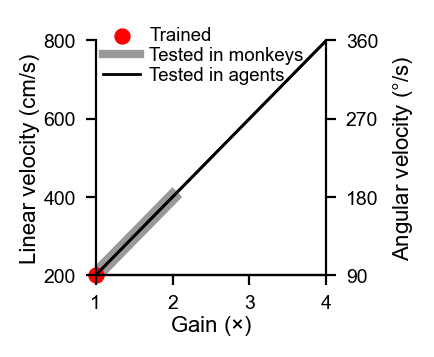

In [20]:
width = 2.1; height = 1.6

gains = np.arange(1, 5)
v_lin = arg.process_gain_default[0].item() * gains * arg.LINEAR_SCALE
v_ang = np.round(np.rad2deg(arg.process_gain_default[1].item() * gains))

with initiate_plot(width, height, 200) as fig:
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(gains, fontsize=fontsize)
    plt.yticks(v_lin, fontsize=fontsize)
    ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
    ax.set_ylabel(r'Linear velocity (cm/s)', fontsize=fontsize + 1)
    ax.set_xlim([gains[0], gains[-1]])
    ax.set_ylim([v_lin[0], v_lin[-1]])
    ax.xaxis.set_label_coords(0.5, -0.16)
    ax.yaxis.set_label_coords(-0.24, 0.5)
    ax.xaxis.set_major_formatter(major_formatter)
    
    training_gains = 1; monk_gains = np.array([1, 2])
    l1 = ax.scatter(training_gains, arg.process_gain_default[0].item() * training_gains * arg.LINEAR_SCALE, 
                    lw=lw * 2, c='r', clip_on=False, s=15, label='Trained')
    l2 = ax.plot(monk_gains, arg.process_gain_default[0].item() * monk_gains * arg.LINEAR_SCALE, 
                 c='gray', lw=lw * 5, zorder=-1, alpha=0.8)
    l2_ = ax.plot([], [], c='gray', lw=lw * 3, label='Tested in monkeys', zorder=-1, alpha=0.8)
    l3 = ax.plot(gains, v_lin, c='k', lw=lw, label='Tested in agents', zorder=-1)
    
    
    bar3 = ax.bar(0, 0, color='none', hatch='\\' * 4)
    ax.plot(gains, v_lin, c='k', lw=lw)
    
    axt = ax.twinx()
    axt.spines['top'].set_visible(False); axt.spines['left'].set_visible(False)
    plt.yticks(v_ang, fontsize=fontsize)
    axt.set_ylabel(r'Angular velocity ($\degree$/s)', fontsize=fontsize + 1)
    axt.set_ylim([v_ang[0], v_ang[-1]])
            
    ax.legend(fontsize=fontsize - 0.3, frameon=False, loc=[0, 0.78], 
              handletextpad=0.5, labelspacing=0.1, ncol=1, columnspacing=0.5)
    
    fig.tight_layout(pad=0.05)
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #            name='gain_illustration'), orientation='portrait', format='pdf', transparent=True)

## b

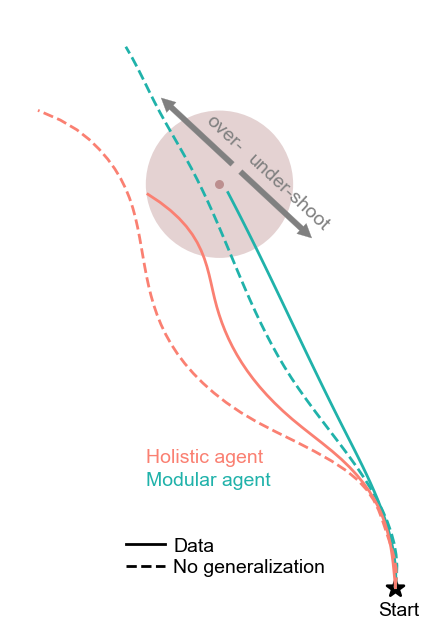

In [80]:
p_idx = 56
width = 2.8
height = 3

dfs = [modular_gain_trajectories[1], holistic_gain_trajectories[1]]
modular_trial, holistic_trial = [df.iloc[p_idx] for df in dfs]

with initiate_plot(width, height, 200) as fig, warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ax = fig.add_subplot(111)
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.axes.xaxis.set_ticks([]); ax.axes.yaxis.set_ticks([])
    
    # modular agent
    mx = modular_trial.pos_x; my = modular_trial.pos_y; mf = UnivariateSpline(my, mx)
    my_new = np.linspace(my[0], my[-1], endpoint=True)
    ax.plot(mf(my_new), my_new, lw=lw, c=modular_c)
    mx_ = modular_trial.sim_pos_x; my_ = modular_trial.sim_pos_y; mf_ = UnivariateSpline(my_, mx_)
    my_new_ = np.linspace(my_[0], my_[-1], endpoint=True)
    ax.plot(mf_(my_new_), my_new_, lw=lw, c=modular_c, ls='--')
    
    # holistic agent
    hx = holistic_trial.pos_x; hy = holistic_trial.pos_y; hf = UnivariateSpline(hy, hx)
    hy_new = np.linspace(hy[0], hy[-1], endpoint=True)
    ax.plot(hf(hy_new), hy_new, lw=lw, c=holistic_c)
    hx_ = holistic_trial.sim_pos_x; hy_ = holistic_trial.sim_pos_y; hf_ = UnivariateSpline(hy_, hx_)
    hy_new_ = np.linspace(hy_[0], hy_[-1], endpoint=True)
    ax.plot(hf_(hy_new_), hy_new_, lw=lw, c=holistic_c, ls='--')
    
    ax.plot([], [], lw=lw, c='k', label='Data')
    ax.plot([], [], lw=lw, c='k', ls='--', label='No generalization')
    
    # target position
    target_x = modular_trial.target_x; target_y = modular_trial.target_y
    cir1 = Circle(xy=[target_x, target_y], 
                  radius=arg.goal_radius_range[0] * arg.LINEAR_SCALE, 
                  alpha=0.4, color=reward_c, lw=0)
    ax.add_patch(cir1)
    ax.scatter(target_x, target_y, c=reward_c, s=5)
    
    # plot initial position
    ax.scatter(0, 0, c='k', s=40, marker='*')
    ax.text(-15, -25, s='Start', fontsize=fontsize)
    

    # labels
    xloc = -220
    ax.text(xloc, 110, s='Holistic agent', fontsize=fontsize, c=holistic_c)
    ax.text(xloc, 90, s='Modular agent', fontsize=fontsize, c=modular_c)
    
    x = np.linspace(target_x * 0.4, target_x * 1.7)
    k = (2 * target_x * target_y) / (target_x**2 - target_y**2)
    k = -1 / k; b = 240
    
    start_x = -140; end_x1 = start_x + 70; end_x2 = start_x -70
    ax.annotate("", xytext=(start_x, k * start_x + b), xy=(end_x1, k * end_x1 + b),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.annotate("", xytext=(start_x, k * start_x + b), xy=(end_x2, k * end_x2 + b),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    
    ax.text(start_x + 7, 315, s='under-shoot', c='gray', 
            rotation=np.rad2deg(np.arctan(k)), fontsize=fontsize)
    ax.text(start_x - 30, 385, s='over-', c='gray', 
            rotation=np.rad2deg(np.arctan(k)), fontsize=fontsize)
    
    ax.legend(fontsize=fontsize, frameon=False, loc=[0.25, 0.05], 
              handletextpad=0.4, labelspacing=0.2, ncol=1, columnspacing=0.5)
    
    fig.tight_layout(pad=0)
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #            name='trial_example'), orientation='portrait', format='pdf', transparent=True)

## g

In [22]:
mean_reward_rate = [np.vstack([np.mean([file[file.task == task].reward_rate 
                                        for task in file.task.unique() if task != 'gain1x'], axis=0)
                               for file in perform_file]).mean(axis=0) 
                    for perform_file in perform_files]
sem_reward_rate = [sem(np.vstack([np.mean([file[file.task == task].reward_rate 
                                           for task in file.task.unique() if task != 'gain1x'], 
                                          axis=0) 
                                  for file in perform_file]), axis=0) 
                   for perform_file in perform_files]
mean_reward_1x = [np.vstack([file[file.task == 'gain1x'].reward_fraction for file in perform_file]).mean(axis=0) 
                  for perform_file in perform_files]

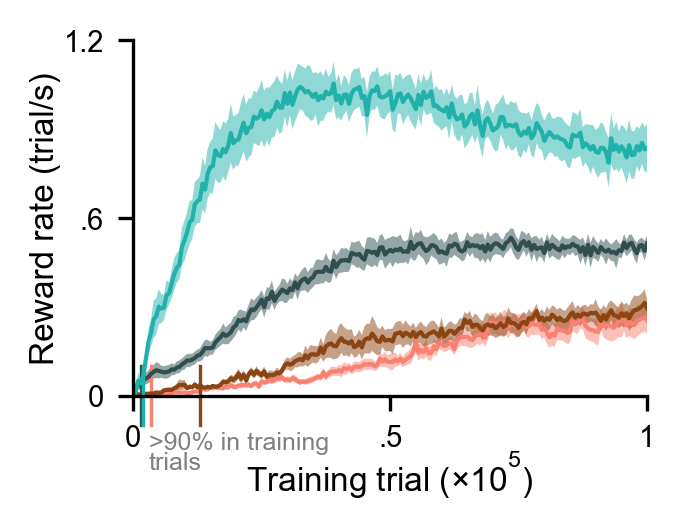

In [23]:
width = 2.1; height = 1.6

xaxis_scale = int(1e5)
yticks = [0, 0.6, 1.2]
xticks = np.array([0, MAX_TRAINING_T / 2, MAX_TRAINING_T])
xticklabels = [my_tickformatter(i, None) for i in xticks / xaxis_scale]
    
with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Training trial ($\times$10$^5$)', fontsize=fontsize + 1)
    ax.set_ylabel('Reward rate (trial/s)', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0], xticks[-1])
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.15)
    ax.yaxis.set_label_coords(-0.14, 0.5)
    ax.yaxis.set_major_formatter(major_formatter)

    xdata = perform_files[0][0].episode.unique()
    for ymean, ystd, y1x, color, label, xshift in zip(mean_reward_rate, sem_reward_rate, mean_reward_1x,
                                                      [holistic_c, moact_hocri_c, hoact_mocri_c, modular_c],
                                                      ['Holistic', 'Modular actor+Holistic critic', 
                                                       'Holistic actor+Modular critic',
                                                       'Modular'],
                                                      [0, 0, -400, 0, 400]):
        ax.plot(xdata, ymean, lw=lw, clip_on=True, c=color, label=label)
        ax.fill_between(xdata, ymean - ystd, ymean + ystd,
                        edgecolor='None', facecolor=color, alpha=0.5)
        ax.plot([xdata[np.where(y1x > 0.9)[0][0]] + xshift] * 2, [0.1, -0.1], lw=lw * 0.8, c=color, 
                ls='-', clip_on=False)
    
    ax.text(3e3, -0.25, '>90% in training\ntrials', fontsize=fontsize - 1, linespacing=0.85, c='gray')
    
    fig.tight_layout(pad=0.1, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #    name='training_perform'), orientation='portrait', format='pdf', transparent=True)

## c

In [24]:
dfs = [bruno_gain_trajectories, schro_gain_trajectories]
dfs = repeat_element(*dfs)

is_sims = [False, True] * int(len(dfs) / 2)
_ = list(map(get_radial_error, dfs, is_sims))

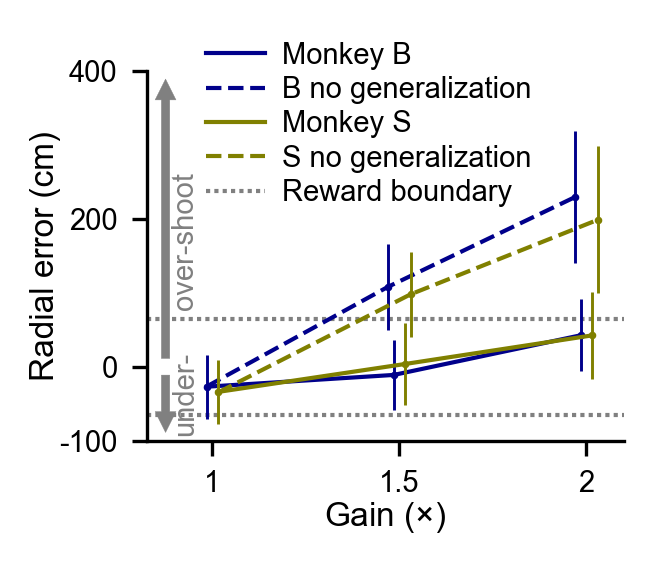

In [25]:
width = 2; height = 1.7
marker = '.'; marker_size = 5; marker_lw = lw * 0.7

xticklabels = [1, 1.5, 2]
xticks = np.arange(len(xticklabels))
yticks = np.array([-100, 0, 200, 400])
target_radius = arg.goal_radius_range[0] * 400

colors = [monkB_c, monkS_c]
labels = ['Monkey B', 'Monkey S', 'B no generalization', 'S no generalization']
dfs = [bruno_gain_trajectories, schro_gain_trajectories]
    
with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
    ax.set_ylabel(r'Radial error (cm)', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0] - 0.35, xticks[-1] + 0.2)
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.16)
    ax.yaxis.set_label_coords(-0.18, 0.5)
    ax.yaxis.set_major_formatter(major_formatter)

    xshifts = [-0.03, 0.03]
    for agent_idx, dfs_ in enumerate(dfs):
        xdata = xticks + xshifts[agent_idx]
        ymean = np.vstack([df.relative_radius_end_shoot for df in dfs_]).mean(axis=1)
        ystd = np.std(np.vstack([df.relative_radius_end_shoot for df in dfs_]), axis=1)
        ax.scatter(xdata, ymean, c=colors[agent_idx],
                   s=marker_size, lw=marker_lw, marker=marker)
        ax.plot(xdata, ymean, c=colors[agent_idx], lw=lw, label=labels[agent_idx])
        ax.errorbar(xdata, ymean, ystd, c=colors[agent_idx], lw=marker_lw, ls='none')
        
        xdata = np.hstack([xdata[0], xticks[1:] + xshifts[agent_idx] * 2])
        ymean = np.vstack([df.sim_relative_radius_end_shoot for df in dfs_]).mean(axis=1)
        ystd = np.std(np.vstack([df.sim_relative_radius_end_shoot for df in dfs_]), axis=1)
        ax.scatter(xdata[1:], ymean[1:], c=colors[agent_idx],
                   s=marker_size, lw=marker_lw, marker=marker)
        ax.plot(xdata, ymean, c=colors[agent_idx], lw=lw, ls='--', label=labels[agent_idx + 2])
        ax.errorbar(xdata[1:], ymean[1:], ystd[1:], c=colors[agent_idx], lw=marker_lw, ls='none')
        
    ax.plot(np.linspace(*ax.get_xlim()), np.linspace(target_radius, target_radius), 
            ls=(0, (1, 1)), c='gray', lw=lw, zorder=-1)
    ax.plot(np.linspace(*ax.get_xlim()), -np.linspace(target_radius, target_radius), 
            ls=(0, (1, 1)), c='gray', lw=lw, zorder=-1, label='Reward boundary')
    
    arrow_x = 0.25
    ax.annotate("", xytext=(-arrow_x, 0), xy=(-arrow_x, ax.get_ylim()[0]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.annotate("", xytext=(-arrow_x, 0), xy=(-arrow_x, ax.get_ylim()[1]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.text(-arrow_x + 0.03, -85, s='under-', c='gray', rotation=90, fontsize=fontsize)
    ax.text(-arrow_x + 0.03, 85, s='over-shoot', c='gray', rotation=90, fontsize=fontsize)
        
    ax.legend(fontsize=fontsize, frameon=False, loc=[0.1, 0.6], 
              handletextpad=0.6, labelspacing=0.22, ncol=1, columnspacing=0.5)
    fig.tight_layout(pad=0.1, rect=(0, 0, 1, 1))

    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #    name='monkey_error'), orientation='portrait', format='pdf', transparent=True)
    

## d

In [26]:
holistic_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                      for idx, df in enumerate(holistic_gain_trajectories_all) if idx != 1]
modular_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                     for idx, df in enumerate(modular_gain_trajectories_all) if idx != 1]

dfs = [holistic_gain_trajectories_all_cat, modular_gain_trajectories_all_cat]
dfs = repeat_element(*dfs)

is_sims = [False, True] * int(len(dfs) / 2)
_ = list(map(get_radial_error, dfs, is_sims))

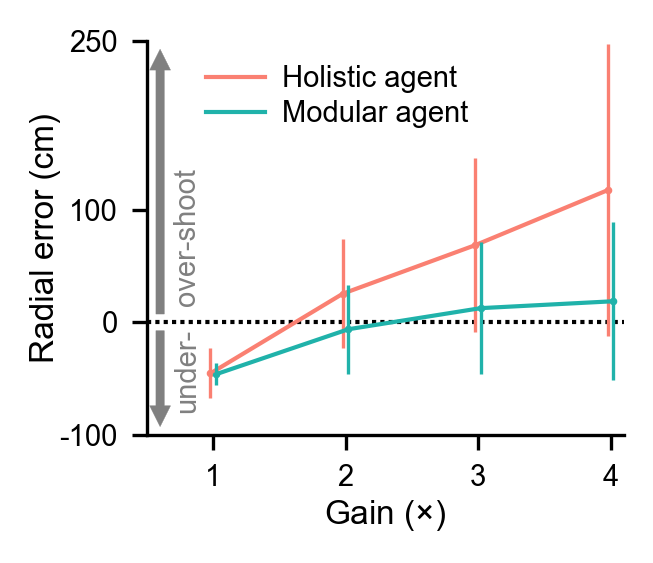

In [27]:
width = 2; height = 1.7
marker = '.'; marker_size = 5; marker_lw = lw * 0.7

xticks = np.arange(1, 5)
yticks = np.array([-100, 0, 100, 250])
target_radius = arg.goal_radius_range[0] * 400

colors = [holistic_c, modular_c]
labels = ['Holistic agent', 'Modular agent']
dfs = [holistic_gain_trajectories_all_cat, modular_gain_trajectories_all_cat]
    
with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
    ax.set_ylabel(r'Radial error (cm)', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0] - 0.5, xticks[-1] + 0.1)
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.16)
    ax.yaxis.set_label_coords(-0.18, 0.5)
    ax.yaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_major_formatter(major_formatter)

    xshifts = [-0.02, 0.02]        
    for agent_idx, dfs_ in enumerate(dfs):
        xdata = xticks + xshifts[agent_idx]
        ymean = np.vstack([df.relative_radius_end_shoot for df in dfs_]).mean(axis=1)
        ystd = np.std(np.vstack([df.relative_radius_end_shoot for df in dfs_]), axis=1)
        ax.scatter(xdata, ymean, c=colors[agent_idx],
                   s=marker_size, lw=marker_lw, marker=marker)
        ax.plot(xdata, ymean, c=colors[agent_idx], lw=lw, label=labels[agent_idx])
        ax.errorbar(xdata, ymean, ystd, c=colors[agent_idx], lw=lw * 0.8, ls='none') 
        
    ax.plot(np.linspace(*ax.get_xlim()), np.linspace(0, 0), ls=(0, (1, 1)), c='k', lw=lw, zorder=-1)
    
    arrow_x = 0.6
    ax.annotate("", xytext=(arrow_x, 0), xy=(arrow_x, ax.get_ylim()[0]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.annotate("", xytext=(arrow_x, 0), xy=(arrow_x, ax.get_ylim()[1]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.text(arrow_x + 0.1, -75, s='under-', c='gray', rotation=90, fontsize=fontsize)
    ax.text(arrow_x + 0.1, 20, s='over-shoot', c='gray', rotation=90, fontsize=fontsize)
        
    ax.legend(fontsize=fontsize, frameon=False, loc=[0.1, 0.75], 
              handletextpad=0.6, labelspacing=0.22, ncol=1, columnspacing=0.5)
    fig.tight_layout(pad=0.1, rect=(0, 0, 1, 1))

    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #    name='agent_error'), orientation='portrait', format='pdf', transparent=True)

## sup 1

In [77]:
holistic_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                      for idx, df in enumerate(holistic_gain_trajectories_all)]
modular_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                     for idx, df in enumerate(modular_gain_trajectories_all)]

dfs = [holistic_gain_trajectories_all_cat, modular_gain_trajectories_all_cat,
       bruno_gain_trajectories, schro_gain_trajectories]
dfs = repeat_element(*dfs)

is_sims = [False, True] * int(len(dfs) / 2)
_ = list(map(get_radial_error, dfs, is_sims))

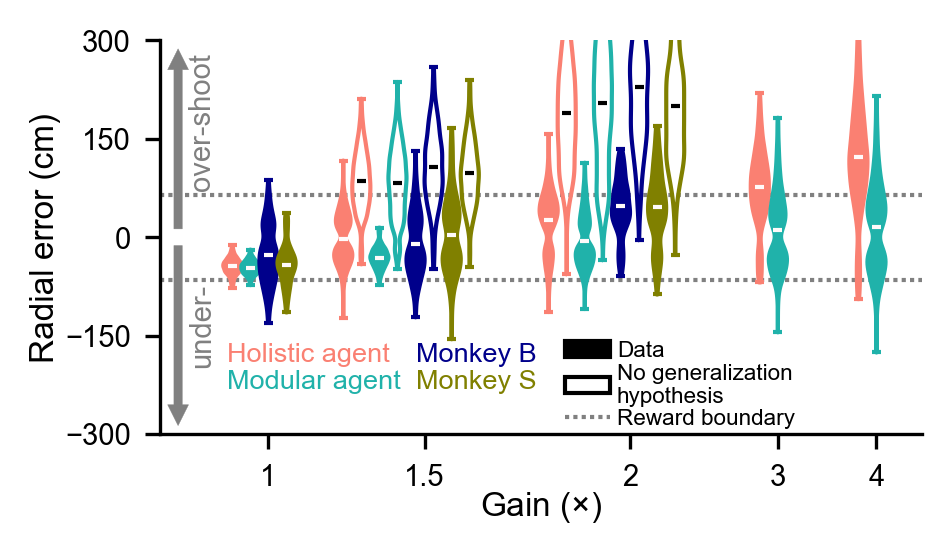

In [79]:
width = 3
height = 1.7
violin_width = 0.11

xticklabels = [1, 1.5] + list(range(2, 5))
xticks = [0.75, 1.7, 2.95, 3.85, 4.45]
yticks = np.arange(-300, 301, 150)
target_radius = arg.goal_radius_range[0] * 400

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain $(\times)$', fontsize=fontsize + 1)
    ax.set_ylabel(r'Radial error (cm)', fontsize=fontsize + 1)
    ax.set_xlim([xticks[0] - 6 * violin_width, xticks[-1] + 2.5 * violin_width]); 
    ax.set_ylim([yticks[0], yticks[-1]])
    ax.yaxis.set_label_coords(-0.13, 0.5)
    ax.xaxis.set_label_coords(0.5, -0.14)
        
    # 1
    positions = [xticks[0] + i * violin_width for i in np.arange(-2, 3)]
    dfs = [holistic_gain_trajectories_all_cat[0], modular_gain_trajectories_all_cat[0], 
           bruno_gain_trajectories[0], schro_gain_trajectories[0]]
    colors = [holistic_c, modular_c, monkB_c, monkS_c]
    for (idx, df), position, color in zip(enumerate(dfs), positions, colors):
        error = df.relative_radius_end_shoot
        vp = ax.violinplot(filter_fliers(error), positions=[position], widths=violin_width, showmeans=True)
        set_violin_plot(vp, facecolor=color, edgecolor=color)
        
    # 1.5, 2
    positions = [xticks[1:3] + i * violin_width for i in np.arange(-5, 5) + 0.5]
    dfs = repeat_element(holistic_gain_trajectories_all_cat[1:3], modular_gain_trajectories_all_cat[1:3], 
                         bruno_gain_trajectories[1:], schro_gain_trajectories[1:])
    colors = repeat_element(holistic_c, modular_c, monkB_c, monkS_c)
    vps = []
    for (idx, df), position, color in zip(enumerate(dfs), positions, colors):
        error = [df_.relative_radius_end_shoot for df_ in df] if idx % 2 == 0\
                                                            else [df_.sim_relative_radius_end_shoot for df_ in df]
        vps.append(ax.violinplot(filter_fliers(error), positions=position, widths=violin_width, showmeans=True))
        facecolor = color if idx % 2  == 0 else 'None'
        set_violin_plot(vps[-1], facecolor=facecolor, edgecolor=color)
        
    # 3, 4
    positions = [xticks[3:] + i * violin_width for i in np.arange(-1, 2)]
    dfs = [holistic_gain_trajectories_all_cat[3:], modular_gain_trajectories_all_cat[3:]]
    colors = [holistic_c, modular_c]
    for (idx, df), position, color in zip(enumerate(dfs), positions, colors):
        error = [df_.relative_radius_end_shoot for df_ in df]
        vp = ax.violinplot(filter_fliers(error), positions=position, widths=violin_width, showmeans=True)
        set_violin_plot(vp, facecolor=color, edgecolor=color)
        
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    line1 = ax.plot(np.linspace(*ax.get_xlim()), np.linspace(target_radius, target_radius), 
                    ls=(0, (1, 1)), c='gray', lw=lw, zorder=-1)
    line2 = ax.plot(np.linspace(*ax.get_xlim()), -np.linspace(target_radius, target_radius), 
                    ls=(0, (1, 1)), c='gray', lw=lw, zorder=-1)
    
    arrow_x = -0.2
    ax.annotate("", xytext=(-arrow_x, 0), xy=(-arrow_x, ax.get_ylim()[0]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.annotate("", xytext=(-arrow_x, 0), xy=(-arrow_x, ax.get_ylim()[1]),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='gray'))
    ax.text(-arrow_x + 0.06, -190, s='under-', c='gray', rotation=90, fontsize=fontsize)
    ax.text(-arrow_x + 0.06, 80, s='over-shoot', c='gray', rotation=90, fontsize=fontsize)
    
    vps_ = []
    for _ in range(2):
        vps_.append(ax.violinplot([1000], widths=violin_width, showmeans=True))
        facecolor = 'k' if _ % 2  == 0 else 'None'
        set_violin_plot(vps_[-1], facecolor=facecolor, edgecolor='k')
        
    ax.legend([vp['bodies'][-1] for vp in vps_] + [line1[0]],
              ['Data', 'No generalization\nhypothesis',
               'Reward boundary'], loc=[0.52, -0.01], frameon=False, fontsize=fontsize - 1.6, 
              ncol=1, columnspacing=0, handletextpad=0.3, labelspacing=0.1)
    
    xloc = 0.5
    ax.text(xloc, -190, s='Holistic agent', fontsize=fontsize - 0.5, c=holistic_c)
    ax.text(xloc, -230, s='Modular agent', fontsize=fontsize - 0.5, c=modular_c)
    xloc = 1.65
    ax.text(xloc, -190, s='Monkey B', fontsize=fontsize - 0.5, c=monkB_c)
    ax.text(xloc, -230, s='Monkey S', fontsize=fontsize - 0.5, c=monkS_c)
    
    plt.tight_layout(pad=0.2, rect=(0.01, 0, 1.01, 1))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #    name='sup_radial_error'), orientation='portrait', format='pdf', transparent=True)

## e

In [64]:
dfs = [holistic_gain_trajectories_all, modular_gain_trajectories_all,
       moho_gain_trajectories_all, homo_gain_trajectories_all]

In [65]:
gain_idx = [0, 2, 3, 4]
max_reward_boundary = int(max([df.relative_radius_end.max() for dfs_ in dfs for df_ in dfs_ for df in df_])) + 1 
hypo_reward_boundaries = np.arange(max_reward_boundary)

targets = modular_gain_trajectories[0][['target_x', 'target_y']].values
shuffled_targets = targets.copy()
rng = default_rng(1); rng.shuffle(shuffled_targets, axis=0)

ydata_gain_agent = []; xdata_gain_agent = []; ysim_gain_agent = []; xsim_gain_agent = []
for dfs_ in tqdm(dfs):
    ydata_gain = []; xdata_gain = []; ysim_gain = []; xsim_gain = []
    for idx in tqdm(gain_idx):
        df_ = dfs_[idx]
        ydata_ = []; xdata_ = []; ysim_ = []; xsim_ = []
        for df in df_:
            ydata = []; xdata = []; ysim = []; xsim = []
            for reward_boundary in hypo_reward_boundaries:
                ydata.append((np.linalg.norm(df[['pos_x_end', 'pos_y_end']] - targets, axis=1) 
                              < reward_boundary).sum() / len(df))
                xdata.append((np.linalg.norm(df[['pos_x_end', 'pos_y_end']] - shuffled_targets, axis=1) 
                              < reward_boundary).sum() / len(df))
                ysim.append((np.linalg.norm(df[['sim_pos_x_end', 'sim_pos_y_end']] - targets, axis=1) 
                             < reward_boundary).sum() / len(df))
                xsim.append((np.linalg.norm(df[['sim_pos_x_end', 'sim_pos_y_end']] - shuffled_targets, axis=1) 
                             < reward_boundary).sum() / len(df))
            ydata_.append(ydata); xdata_.append(xdata); ysim_.append(ysim); xsim_.append(xsim)  
        ydata_gain.append(ydata_)
        xdata_gain.append(xdata_)
        ysim_gain.append(ysim_)
        xsim_gain.append(xsim_)
        
    ydata_gain_agent.append(ydata_gain)
    xdata_gain_agent.append(xdata_gain)
    ysim_gain_agent.append(ysim_gain)
    xsim_gain_agent.append(xsim_gain)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

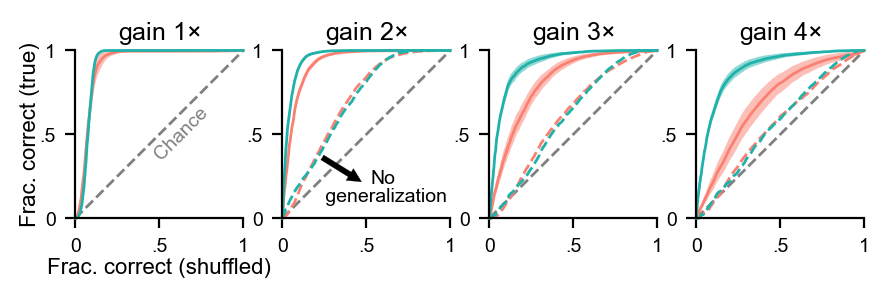

In [66]:
width = 4.25; height = 1.4
title_pad = 4

ticks = np.linspace(0, 1, 3)

titles = [fr'gain {i}$\times$' for i in range(1, 5)]
colors = [holistic_c, modular_c]

with initiate_plot(width, height, 200) as fig:
    for idx, f_idx in enumerate(range(1, 5)):
        ax = fig.add_subplot(1, 4, f_idx)
        ax.set_aspect('equal')
        ax.set_title(titles[idx], fontsize=fontsize + 2, pad=title_pad) 
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.xticks(ticks, fontsize=fontsize)
        plt.yticks(ticks, fontsize=fontsize)
        ax.xaxis.set_major_formatter(major_formatter)
        ax.yaxis.set_major_formatter(major_formatter)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xlim([ticks[0], ticks[-1]])
        ax.set_ylim(ax.get_xlim())

        for agent_idx in range(len(colors)):
            xmean = np.vstack(xdata_gain_agent[agent_idx][idx]).mean(axis=0)
            ymean = np.vstack(ydata_gain_agent[agent_idx][idx]).mean(axis=0)
            yerror = sem(np.vstack(ydata_gain_agent[agent_idx][idx]), axis=0)

            ax.plot(xmean, ymean, c=colors[agent_idx], lw=lw, clip_on=False)
            ax.fill_between(xmean, ymean - yerror, ymean + yerror,
                            edgecolor='None', facecolor=colors[agent_idx], alpha=0.5)
            if idx != 0:
                xmean = np.vstack(xsim_gain_agent[agent_idx][idx]).mean(axis=0)
                ymean = np.vstack(ysim_gain_agent[agent_idx][idx]).mean(axis=0)
                ax.plot(xmean, ymean, c=colors[agent_idx], lw=lw, clip_on=False, ls='--')
        ax.plot(np.linspace(*ax.get_xlim()), np.linspace(*ax.get_ylim()), 
                c='gray', lw=lw, clip_on=False, ls='--', alpha=1, zorder=-1)

        if f_idx == 1:
            ax.set_xlabel('Frac. correct (shuffled)', fontsize=fontsize + 1)
            ax.set_ylabel('Frac. correct (true)', fontsize=fontsize + 1)
            ax.xaxis.set_label_coords(0.5, -0.23)
            ax.yaxis.set_label_coords(-0.21, 0.5)
            ax.text(0.45, 0.35, 'Chance', c='gray', fontsize=fontsize, rotation=45)
        elif f_idx == 2:
            ax.annotate("", xytext=(0.21, 0.38), xy=(0.5, 0.2),
                arrowprops=dict(arrowstyle="simple", lw=0.1, color='k'))
            ax.text(0.6, 0.1, 'No\n generalization', fontsize=fontsize, ha='center', linespacing=1)
    
    fig.tight_layout(pad=0.1, w_pad=-0.1, h_pad=0.2, rect=(0.005, 0, 1.005, 1))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #    name='ROC'), orientation='portrait', format='pdf', transparent=True)

## f

In [67]:
auc_data = [[[np.trapz(ydata_gain_agent[agent_idx][gain_idx][idx], xdata_gain_agent[agent_idx][gain_idx][idx])
              for idx in range(8)] for gain_idx in range(4)] for agent_idx in range(4)]

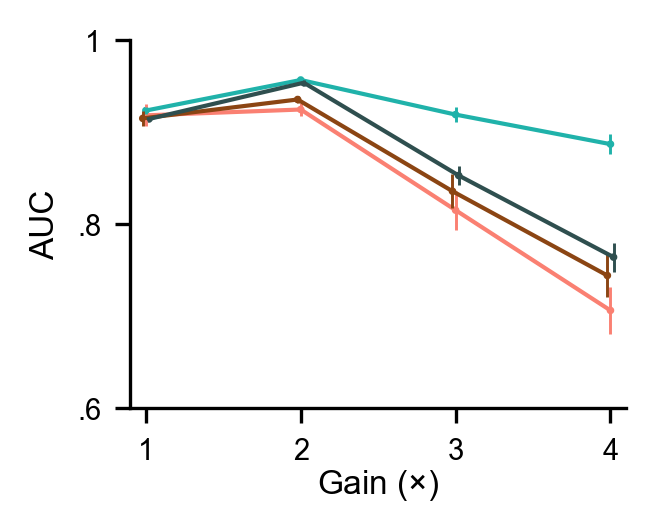

In [68]:
width = 2; height = 1.6
marker = '.'; marker_size = 5; marker_lw = lw * 0.7

yticks = np.linspace(0.6, 1, 3)
xticks = np.arange(1, 5)
colors = [holistic_c, modular_c, moact_hocri_c, hoact_mocri_c]
    
with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain $(\times)$', fontsize=fontsize + 1)
    ax.set_ylabel('AUC', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0] - 0.1, xticks[-1] + 0.1)
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.16)
    ax.yaxis.set_label_coords(-0.14, 0.5)
    ax.yaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_major_formatter(major_formatter)

    xshifts = [0, 0, -0.02, 0.02]   
    for agent_idx in range(len(colors)):
        xdata = xticks + xshifts[agent_idx]
        ymean = np.vstack(auc_data[agent_idx]).mean(axis=1)
        yerror = sem(np.vstack(auc_data[agent_idx]), axis=1)
        ax.scatter(xdata, ymean, edgecolors=colors[agent_idx], facecolors='none',
                   s=marker_size, lw=0.7, marker=marker)
        ax.plot(xdata, ymean, c=colors[agent_idx], lw=lw)
        ax.errorbar(xdata, ymean, yerror, c=colors[agent_idx], lw=marker_lw, ls='none')
        
    text_x = 1.05
    fig.tight_layout(pad=0.1, rect=(0, 0, 1, 1))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #            name='AUC'), orientation='portrait', format='pdf', transparent=True)

## sup c and d

In [69]:
holistic_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                      for idx, df in enumerate(holistic_gain_trajectories_all) if idx != 1]
moho_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                  for idx, df in enumerate(moho_gain_trajectories_all) if idx != 1]
homo_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                  for idx, df in enumerate(homo_gain_trajectories_all) if idx != 1]
modular_gain_trajectories_all_cat = [pd.concat(df, ignore_index=True) 
                                     for idx, df in enumerate(modular_gain_trajectories_all) if idx != 1]


dfs_agent = [holistic_gain_trajectories_all_cat, moho_gain_trajectories_all_cat, homo_gain_trajectories_all_cat,
             modular_gain_trajectories_all_cat]
curvatures_agent = list(map(compute_curvature, dfs_agent))
dfs_monkey = [bruno_gain_trajectories, schro_gain_trajectories]
curvatures_monkey = list(map(compute_curvature, dfs_monkey))

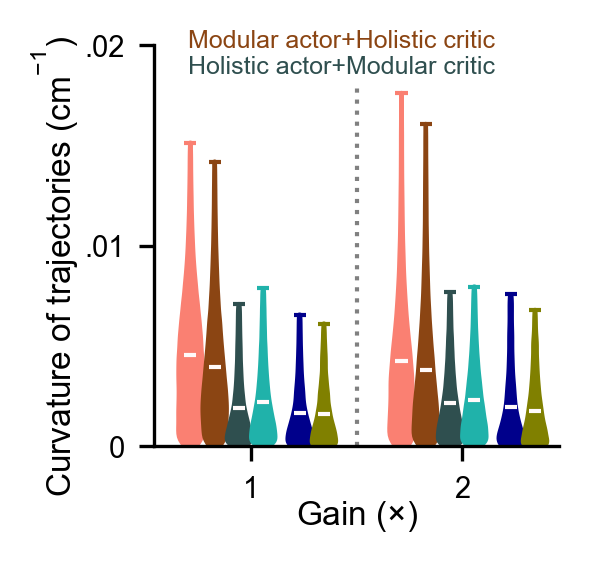

In [70]:
width = 1.8
height = 1.7
violin_width = 0.115

xticks = np.array([1, 2])
yticks = np.linspace(0, 0.02, 3)

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
    ax.set_ylabel(r'Curvature of trajectories (cm$^{-1}$)', fontsize=fontsize + 1)
    ax.set_xlim([xticks[0] - 4 * violin_width, xticks[-1] + 4 * violin_width]); 
    ax.set_ylim([yticks[0], yticks[-1]])
    ax.yaxis.set_label_coords(-0.18, 0.45)
    ax.xaxis.set_label_coords(0.5, -0.13)
    ax.yaxis.set_major_formatter(major_formatter)
    
    positions = [xticks + i * violin_width for i in np.arange(-2.5, 2)]
    colors = [holistic_c, moact_hocri_c, hoact_mocri_c, modular_c]
    for (idx, curv), position, color in zip(enumerate(curvatures_agent), positions, colors):
        locals()[f'vp{idx}'] = ax.violinplot(filter_fliers([abs(data) for i, data in enumerate(curv) 
                                                            if i == 0 or i == 1]), 
                                             positions=position, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx}'], facecolor=color, edgecolor=color)
        
    positions = [xticks + i * violin_width for i in np.arange(2, 4)]
    colors = [monkB_c, monkS_c]
    for (idx, curv), position, color in zip(enumerate(curvatures_monkey), positions, colors):
        locals()[f'vp{idx + len(dfs_agent)}'] = ax.violinplot(
                                        filter_fliers([abs(data) for i, data in enumerate(curv) if i != 1]), 
                                        positions=position, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx + len(dfs_agent)}'], facecolor=color, edgecolor=color)
        
    plt.xticks(xticks, fontsize=fontsize)
    
    ax.plot(np.linspace(1.5, 1.5), np.linspace(0, 0.018), c='gray', ls=':', lw=lw) 
    
    text_x = 0.7
    ax.text(text_x, 0.016 + 0.0013 * 3, 'Modular actor+Holistic critic', c=moact_hocri_c, fontsize=fontsize - 1)
    ax.text(text_x, 0.016 + 0.0013 * 2, 'Holistic actor+Modular critic', c=hoact_mocri_c, fontsize=fontsize - 1)
    
    plt.tight_layout(pad=0.1, rect=(0.01, 0, 1.01, 1))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #             name='sup_curvature'), orientation='portrait', format='pdf', transparent=True)

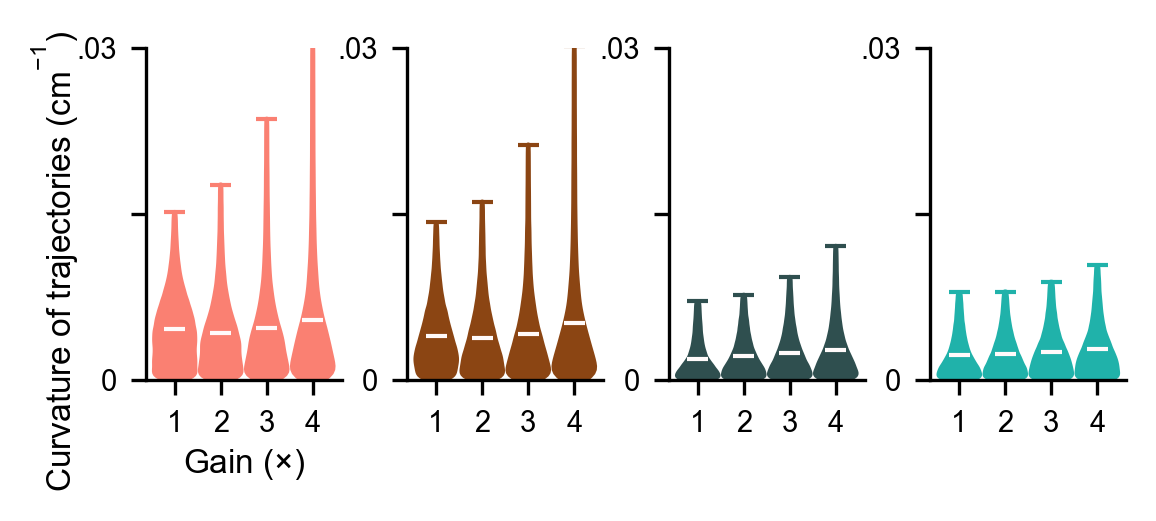

In [71]:
width = 3.7
height = 1.55
violin_width = 0.9

xticks = range(1, 5)
yticks = np.linspace(0, 0.03, 3)
yticklabels = [0, None, '.03']

colors = [holistic_c, moact_hocri_c, hoact_mocri_c, modular_c]

with initiate_plot(width, height, 300) as fig:
    for f_idx in range(4):
        ax = fig.add_subplot(1, 4, f_idx + 1)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.yticks(yticks, yticklabels, fontsize=fontsize)
        ax.set_xlabel('', fontsize=fontsize)
        ax.set_ylabel('', fontsize=fontsize)
        ax.set_xlim([xticks[0] - 0.7 * violin_width, xticks[-1] + 0.7 * violin_width]); 
        ax.set_ylim([yticks[0], yticks[-1]])
        
        positions = xticks
        locals()[f'vp{idx}'] = ax.violinplot(filter_fliers([abs(data) for data in curvatures_agent[f_idx]]), 
                                             positions=positions, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx}'], facecolor=colors[f_idx], edgecolor=colors[f_idx])
        plt.xticks(xticks, fontsize=fontsize)
        
        if f_idx == 0:
            ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
            ax.set_ylabel(r'Curvature of trajectories (cm$^{-1}$)', fontsize=fontsize + 1)
            ax.yaxis.set_label_coords(-0.33, 0.36)
            ax.xaxis.set_label_coords(0.5, -0.2)
        
    plt.tight_layout(pad=0.2, w_pad=-0.1, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #             name='sup_curvature2'), orientation='portrait', format='pdf', transparent=True)

## sup e and f

In [72]:
lengths_agent = list(map(compute_length, dfs_agent))
lengths_monkey = list(map(compute_length, dfs_monkey))

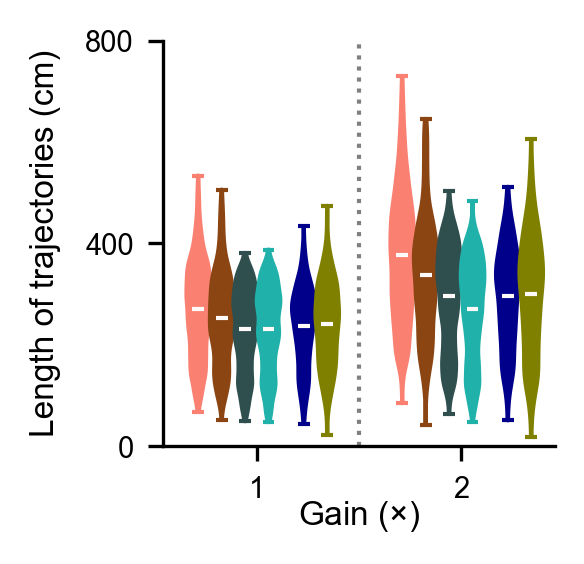

In [73]:
width = 1.8
height = 1.7
violin_width = 0.115

xticks = np.array([1, 2])
yticks = np.linspace(0, 800, 3)

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
    ax.set_ylabel(r'Length of trajectories (cm)', fontsize=fontsize + 1)
    ax.set_xlim([xticks[0] - 4 * violin_width, xticks[-1] + 4 * violin_width]); 
    ax.set_ylim([yticks[0], yticks[-1]])
    ax.yaxis.set_label_coords(-0.26, 0.5)
    ax.xaxis.set_label_coords(0.5, -0.13)
    ax.yaxis.set_major_formatter(major_formatter)
    
    positions = [xticks + i * violin_width for i in np.arange(-2.5, 2)]
    colors = [holistic_c, moact_hocri_c, hoact_mocri_c, modular_c]
    for (idx, length), position, color in zip(enumerate(lengths_agent), positions, colors):
        locals()[f'vp{idx}'] = ax.violinplot(filter_fliers([abs(data) for i, data in enumerate(length) 
                                                            if i == 0 or i == 1]), 
                                             positions=position, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx}'], facecolor=color, edgecolor=color)
        
    positions = [xticks + i * violin_width for i in np.arange(2, 4)]
    colors = [monkB_c, monkS_c]
    for (idx, length), position, color in zip(enumerate(lengths_monkey), positions, colors):
        locals()[f'vp{idx + len(dfs_agent)}'] = ax.violinplot(
                                        filter_fliers([abs(data) for i, data in enumerate(length) if i != 1]), 
                                        positions=position, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx + len(dfs_agent)}'], facecolor=color, edgecolor=color)
        
    plt.xticks(xticks, fontsize=fontsize)
    
    ax.plot(np.linspace(1.5, 1.5), np.linspace(*ax.get_ylim()), c='gray', ls=':', lw=lw) 
    
    plt.tight_layout(pad=0.1, rect=(0.01, 0, 1.01, 1))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #             name='sup_length'), orientation='portrait', format='pdf', transparent=True)

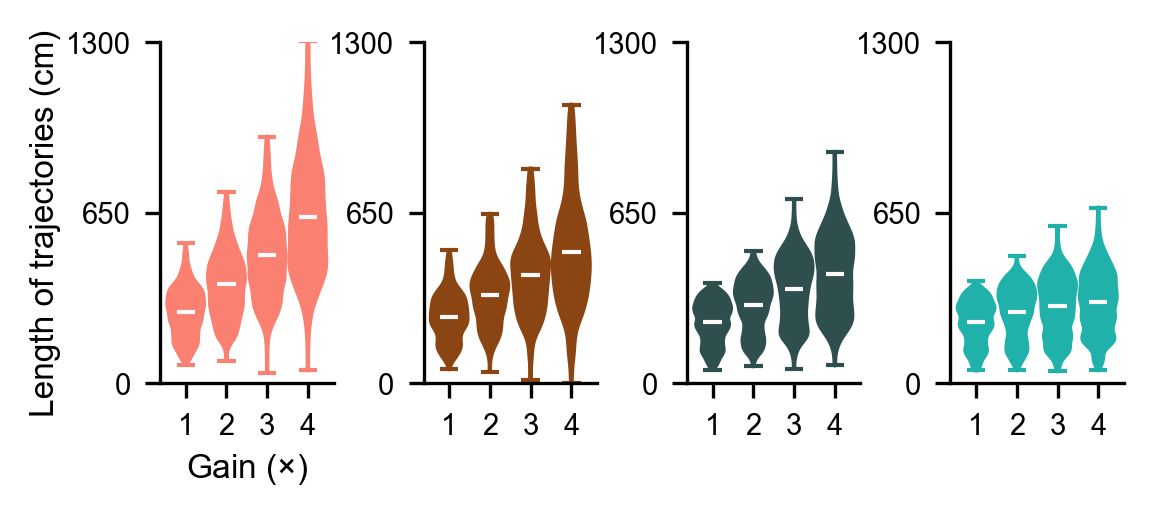

In [74]:
width = 3.7
height = 1.55
violin_width = 0.9

xticks = range(1, 5)
yticks = np.linspace(0, 1300, 3)

colors = [holistic_c, moact_hocri_c, hoact_mocri_c, modular_c]

with initiate_plot(width, height, 300) as fig:
    for f_idx in range(4):
        ax = fig.add_subplot(1, 4, f_idx + 1)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.yticks(yticks, fontsize=fontsize)
        ax.set_xlabel('', fontsize=fontsize)
        ax.set_ylabel('', fontsize=fontsize)
        ax.set_xlim([xticks[0] - 0.7 * violin_width, xticks[-1] + 0.7 * violin_width]); 
        ax.set_ylim([yticks[0], yticks[-1]])
        
        positions = xticks
        locals()[f'vp{idx}'] = ax.violinplot(filter_fliers([abs(data) for data in lengths_agent[f_idx]]), 
                                             positions=positions, widths=violin_width, showmeans=True)
        set_violin_plot(locals()[f'vp{idx}'], facecolor=colors[f_idx], edgecolor=colors[f_idx])
        plt.xticks(xticks, fontsize=fontsize)
        
        if f_idx == 0:
            ax.set_xlabel(r'Gain ($\times$)', fontsize=fontsize + 1)
            ax.set_ylabel(r'Length of trajectories (cm)', fontsize=fontsize + 1)
            ax.yaxis.set_label_coords(-0.57, 0.47)
            ax.xaxis.set_label_coords(0.5, -0.2)
        
    plt.tight_layout(pad=0.1, w_pad=-0.1, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #             name='sup_length2'), orientation='portrait', format='pdf', transparent=True)

## sup b

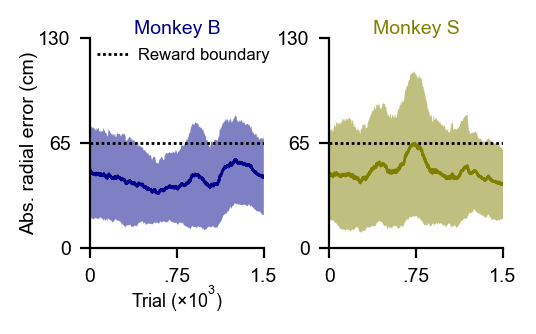

In [75]:
width = 2.5
height = 1.5
title_pad = 0

xticks = [0, 750, 1500]; xticklabels = ['0', '.75', '1.5']
yticks = [0, 65, 130]
titles = ['Monkey B', 'Monkey S']
colors = [monkB_c, monkS_c]

smoothing_window = int(xticks[-1] / 10)

with initiate_plot(width, height, 200) as fig:
    for idx, fig_idx in enumerate(range(1, 3)):
        ax = fig.add_subplot(1, 2, fig_idx)
        ax.set_title(titles[idx], fontsize=fontsize, pad=title_pad, c=colors[idx])
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.xticks(xticks, xticklabels, fontsize=fontsize)
        plt.yticks(yticks, fontsize=fontsize)
        ax.set_xlabel('', fontsize=fontsize)
        ax.set_ylabel('', fontsize=fontsize)
        ax.set_xlim([xticks[0], xticks[-1]]); ax.set_ylim([yticks[0], yticks[-1]])
        
        df = bruno_gain_trajectory_all if idx == 0 else schro_gain_trajectory_all
        data = df[df.gain_v == 300].relative_radius_end.iloc[:xticks[-1]]
        xdata = np.arange(len(data)) + 1
        ymean = data.rolling(smoothing_window, center=True, min_periods=0).mean()
        ystd = data.rolling(smoothing_window, center=True, min_periods=0).std()
        
        line = ax.plot(np.linspace(*ax.get_xlim()), 
                       np.linspace(*([arg.goal_radius_range[0] * arg.LINEAR_SCALE] * 2)), 
                       c='k', lw=lw, ls=(0, (1, 1)), label='Reward boundary')
        ax.plot(xdata, ymean, lw=lw, c=colors[idx])
        ax.fill_between(xdata, ymean - ystd, ymean + ystd, edgecolor='None', facecolor=colors[idx], alpha=0.5)
        
        if fig_idx == 1:
            ax.set_xlabel(r'Trial ($\times$10$^3$)', fontsize=fontsize - 0.5)
            ax.set_ylabel(r'Abs. radial error (cm)', fontsize=fontsize)
            ax.yaxis.set_label_coords(-0.3, 0.5)
            ax.xaxis.set_label_coords(0.5, -0.17)
            ax.legend(loc=[0, 0.85], frameon=False, 
                      fontsize=fontsize - 1, labelspacing=0.2,
                      ncol=1, columnspacing=0.1, handletextpad=0.5)
        
    plt.tight_layout(pad=0.05, w_pad=0)
        
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure2/raw/{name}.pdf'.format(
    #            name='learning_effect'), orientation='portrait', format='pdf', transparent=True)